In [1]:

# Imports
import os, json, re, warnings, random
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from imblearn.over_sampling import SMOTE
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

In [3]:
# Set your CSV file path in the Colab workspace
CSV_PATH = "/content/Depression_Student_Dataset.csv"  # <-- change to your actual filename

# Try loading from path; if not found, offer upload
if not Path(CSV_PATH).exists():
    print(f"CSV not found at {CSV_PATH}. Upload a CSV now...")
    try:
        from google.colab import files
        uploaded = files.upload()
        CSV_PATH = next(iter(uploaded))  # use the first uploaded file
    except Exception as e:
        raise FileNotFoundError("Please set CSV_PATH correctly or upload a CSV.")

df = pd.read_csv(CSV_PATH)
print("Loaded:", CSV_PATH, "shape:", df.shape)
display(df.head(10))


Loaded: /content/Depression_Student_Dataset.csv shape: (502, 11)


,Gender,Age,Academic Pressure,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,28,2.0,4.0,7-8 hours,Moderate,Yes,9,2,Yes,No
1,Male,28,4.0,5.0,5-6 hours,Healthy,Yes,7,1,Yes,No
2,Male,25,1.0,3.0,5-6 hours,Unhealthy,Yes,10,4,No,Yes
3,Male,23,1.0,4.0,More than 8 hours,Unhealthy,Yes,7,2,Yes,No
4,Female,31,1.0,5.0,More than 8 hours,Healthy,Yes,4,2,Yes,No
5,Male,19,4.0,4.0,5-6 hours,Unhealthy,Yes,1,4,Yes,Yes
6,Female,34,4.0,2.0,More than 8 hours,Moderate,Yes,6,2,No,Yes
7,Female,20,4.0,1.0,More than 8 hours,Healthy,Yes,3,4,Yes,Yes
8,Female,33,1.0,4.0,More than 8 hours,Moderate,No,10,3,No,No
9,Male,33,4.0,3.0,Less than 5 hours,Unhealthy,Yes,10,1,No,Yes


In [4]:
# If your target column is known, set it here; otherwise leave as None for auto-detect
TARGET_COL = None  # e.g., "Depression" or "depressed" etc.

def infer_target_column(df: pd.DataFrame) -> str:
    # Priority names
    common_names = ["depressed","is_depressed","depression","label","target","class","outcome","diagnosis"]
    low = {c.lower(): c for c in df.columns}
    for name in common_names:
        if name in low:
            return low[name]
    # Any binary column (2 unique non-null values)
    binaries = [c for c in df.columns if df[c].nunique(dropna=True) == 2]
    if binaries:
        # prefer likely names
        pref = [c for c in binaries if any(k in c.lower() for k in ["dep","label","target","class","diagnosis"])]
        return pref[0] if pref else binaries[0]
    # Last resort: last column
    return df.columns[-1]

target_col = TARGET_COL or infer_target_column(df)
print("Target column:", target_col)

def map_y_to_binary(y: pd.Series) -> pd.Series:
    # numeric -> if already 0/1 keep; else binarize by median
    if pd.api.types.is_numeric_dtype(y):
        vals = set(pd.unique(y.dropna()))
        if vals <= {0,1}:
            return y.astype(int)
        return (y > y.median()).astype(int)

    # textual -> heuristic mapping
    y2 = y.astype(str).str.lower().str.strip()
    pos = {"depressed","yes","y","true","1","positive","high"}
    neg = {"not depressed","no","n","false","0","negative","low","normal"}
    out = []
    for v in y2:
        if v in pos or ("depress" in v and "not" not in v):
            out.append(1)
        elif v in neg or ("not depressed" in v):
            out.append(0)
        else:
            out.append(np.nan)
    yb = pd.Series(out, index=y.index)
    if yb.isna().any():
        yb = yb.fillna(int(yb.dropna().mode()[0])) if yb.dropna().nunique()==2 else yb.fillna(0)
    return yb.astype(int)


Target column: Depression


In [5]:
df_raw = df.copy()

# 1) Strip whitespace from string columns; unify case
for c in df.columns:
    if df[c].dtype == object:
        df[c] = df[c].astype(str).str.strip()
        # normalize yes/no style for common fields (optional)
        if df[c].str.lower().isin(["yes","no","y","n","true","false","1","0"]).mean() > 0.5:
            df[c] = (df[c].str.lower()
                     .replace({"y":"yes","n":"no","true":"yes","false":"no","1":"yes","0":"no"}))

# 2) Remove exact duplicate rows
before = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
after = df.shape[0]
print(f"Removed duplicates: {before - after}")

# 3) Basic type coercions (try numeric where possible)
for c in df.columns:
    if c == target_col:
        continue
    # attempt numeric conversion; if most values convert fine, keep numeric
    s = pd.to_numeric(df[c], errors="coerce")
    if s.notna().mean() > 0.7:
        df[c] = s

# 4) Show missingness summary
miss = df.isna().mean().sort_values(ascending=False)
display(pd.DataFrame({"missing_rate": miss}).head(20))


Removed duplicates: 0


,missing_rate
Gender,0.0
Age,0.0
Academic Pressure,0.0
Study Satisfaction,0.0
Sleep Duration,0.0
Dietary Habits,0.0
Have you ever had suicidal thoughts ?,0.0
Study Hours,0.0
Financial Stress,0.0
Family History of Mental Illness,0.0


Shape: (502, 11)


,Gender,Age,Academic Pressure,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,28,2.0,4.0,7-8 hours,Moderate,yes,9,2,yes,no
1,Male,28,4.0,5.0,5-6 hours,Healthy,yes,7,1,yes,no
2,Male,25,1.0,3.0,5-6 hours,Unhealthy,yes,10,4,no,yes
3,Male,23,1.0,4.0,More than 8 hours,Unhealthy,yes,7,2,yes,no
4,Female,31,1.0,5.0,More than 8 hours,Healthy,yes,4,2,yes,no



Data Types:


,Gender,Age,Academic Pressure,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Study Hours,Financial Stress,Family History of Mental Illness,Depression
dtype,object,int64,float64,float64,object,object,object,int64,int64,object,object



Target distribution (0=Not Depressed, 1=Depressed):


,proportion
1,0.501992
0,0.498008



Features: 5 categorical, 5 numeric

Top categorical cardinalities:


,n_unique
Sleep Duration,4
Dietary Habits,3
Gender,2
Have you ever had suicidal thoughts ?,2
Family History of Mental Illness,2


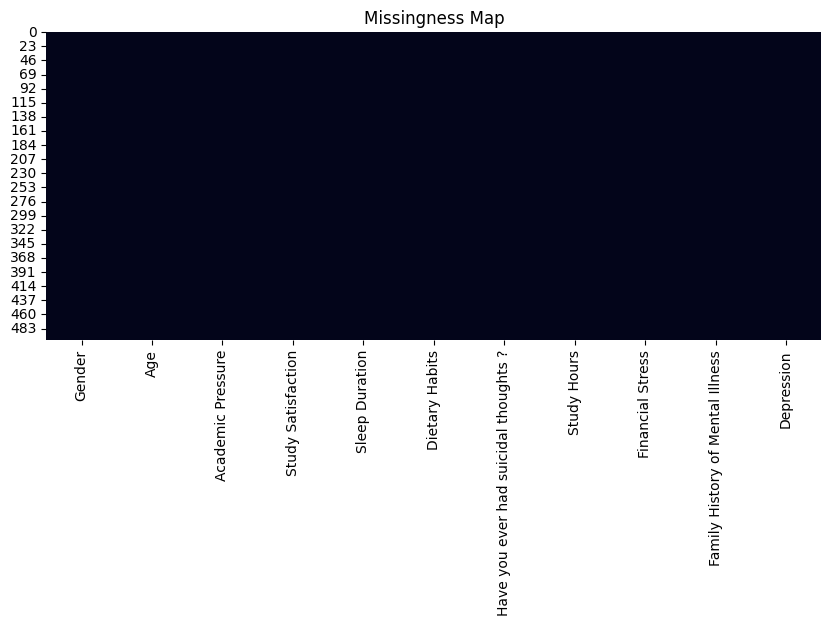

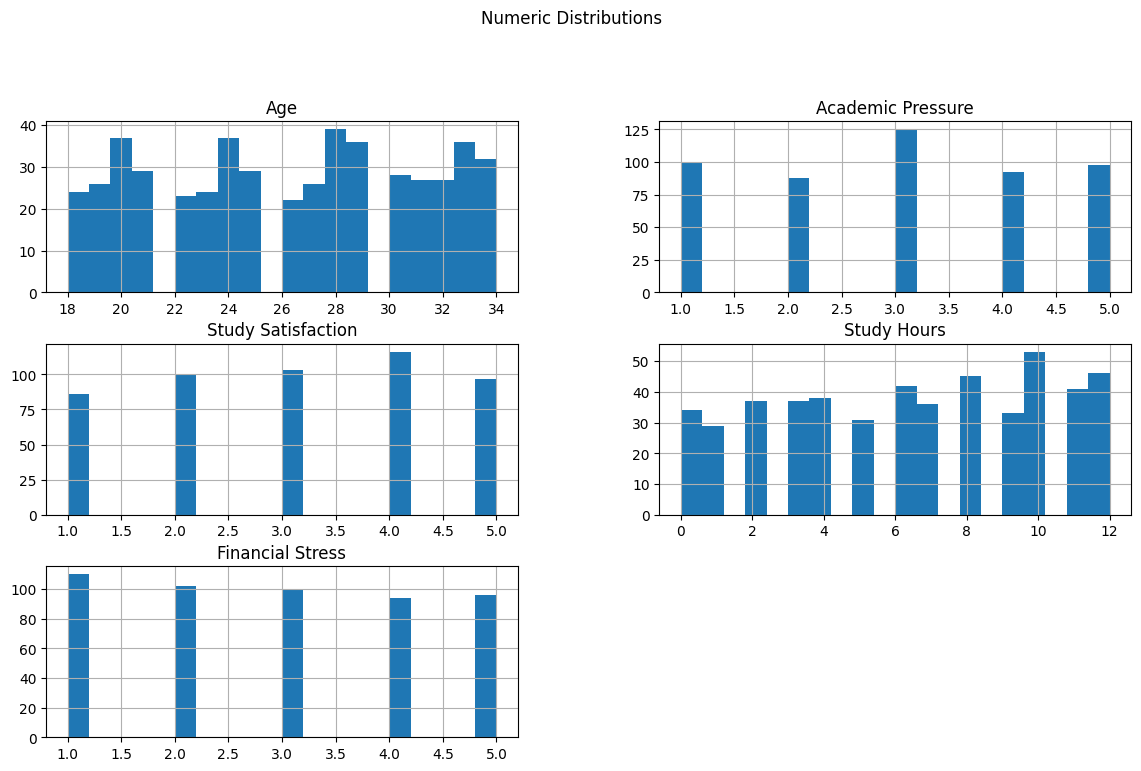

,corr_with_target
Academic Pressure,0.476259
Financial Stress,0.296846
Study Hours,0.200441
Age,-0.215625
Study Satisfaction,-0.293484



Categorical: Gender


,positive_rate
Gender,
Male,0.516854
Female,0.485106



Categorical: Sleep Duration


,positive_rate
Sleep Duration,
7-8 hours,0.523438
5-6 hours,0.520325
Less than 5 hours,0.520325
More than 8 hours,0.445312


...

,positive_rate
Dietary Habits,
Unhealthy,0.627219
Moderate,0.476744
Healthy,0.397516



Categorical: Have you ever had suicidal thoughts ?


,positive_rate
Have you ever had suicidal thoughts ?,
yes,0.726923
no,0.260331



Categorical: Family History of Mental Illness


,positive_rate
Family History of Mental Illness,
yes,0.531646
no,0.475472


In [7]:
print("Shape:", df.shape)
display(df.head())

# Info & dtypes
print("\nData Types:")
display(pd.DataFrame(df.dtypes, columns=["dtype"]).T)

# Target balance
y = map_y_to_binary(df[target_col])
print("\nTarget distribution (0=Not Depressed, 1=Depressed):")
display(y.value_counts(normalize=True).rename("proportion").to_frame())

# Numeric vs Categorical split
categorical_cols = [c for c in df.columns if c != target_col and (df[c].dtype == object or str(df[c].dtype).startswith("category"))]
numeric_cols = [c for c in df.columns if c != target_col and c not in categorical_cols]
print(f"\nFeatures: {len(categorical_cols)} categorical, {len(numeric_cols)} numeric")

# Cardinalities for categoricals (helps decide select fields in UI)
cat_card = df[categorical_cols].nunique().sort_values(ascending=False)
print("\nTop categorical cardinalities:")
display(cat_card.head(20).to_frame("n_unique"))

# Missingness heatmap (optional)
plt.figure(figsize=(10,4))
sns.heatmap(df.isna(), cbar=False)
plt.title("Missingness Map")
plt.show()

# Numeric distributions
if numeric_cols:
    df[numeric_cols].hist(figsize=(14,8), bins=20)
    plt.suptitle("Numeric Distributions", y=1.02)
    plt.show()

# Correlations with target (numerics)
if numeric_cols:
    corr_with_y = df[numeric_cols].corrwith(y, method="pearson")
    display(pd.DataFrame({"corr_with_target": corr_with_y}).sort_values("corr_with_target", ascending=False))

# Categorical top values and relation to target (rate table)
def cat_rate_table(c):
    tmp = df[[c]].assign(y=y).dropna()
    rate = tmp.groupby(c)["y"].mean().sort_values(ascending=False)
    return rate.to_frame("positive_rate")

for c in categorical_cols[:10]:  # limit display
    print(f"\nCategorical: {c}")
    display(cat_rate_table(c).head(10))

Model Comparison:


,model,cv_auc,holdout_acc,holdout_f1,holdout_auc
0,LogisticRegression,0.998402,1.000000,1.000000,1.000000
1,RandomForest,0.951328,0.930693,0.934579,0.982157
2,GradientBoosting,0.964445,0.910891,0.915888,0.989020


Best model: LogisticRegression  (score=1.0000)

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        50
           1     1.0000    1.0000    1.0000        51

    accuracy                         1.0000       101
   macro avg     1.0000    1.0000    1.0000       101
weighted avg     1.0000    1.0000    1.0000       101



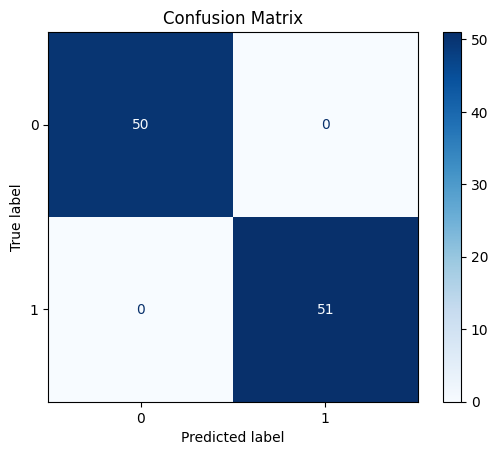

In [9]:
X = df.drop(columns=[target_col])
y = map_y_to_binary(df[target_col])

# Preprocess pipelines
numeric_tf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_tf = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer([
    ("num", numeric_tf, numeric_cols),
    ("cat", categorical_tf, categorical_cols)
])

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Models
models = {
    "LogisticRegression": LogisticRegression(max_iter=2000),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, class_weight="balanced"),
    "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE)
}

# Train & evaluate
results = []
best_name, best_metric, best_pipe = None, -1.0, None

for name, clf in models.items():
    pipe = Pipeline([("preprocess", preprocess), ("model", clf)])
    # CV AUC may fail if folds get one class—ignore gracefully
    try:
        cv_auc = float(np.mean(cross_val_score(pipe, X_train, y_train, cv=5, scoring="roc_auc")))
    except Exception:
        cv_auc = np.nan
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:,1] if hasattr(clf, "predict_proba") else None
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
    results.append({"model": name, "cv_auc": cv_auc, "holdout_acc": acc, "holdout_f1": f1, "holdout_auc": auc})
    metric = auc if not np.isnan(auc) else acc
    if metric > best_metric:
        best_metric, best_name, best_pipe = metric, name, pipe

res_df = pd.DataFrame(results)
print("Model Comparison:")
display(res_df)

print(f"Best model: {best_name}  (score={best_metric:.4f})")

# Evaluation plots
y_pred = best_pipe.predict(X_test)
y_proba = best_pipe.predict_proba(X_test)[:,1] if hasattr(best_pipe.named_steps["model"], "predict_proba") else None

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [10]:
# Fixed selectable options: take unique values seen in data (cap to 30 per field)
cat_options = {}
for c in categorical_cols:
    vals = (df[c].dropna().astype(str).unique().tolist())
    # Optional: prioritize common labels like 'satisfaction'/'satisfied' etc.
    vals_sorted = sorted(vals, key=lambda v: (v.lower() not in ["very satisfied","satisfied","neutral","dissatisfied","very dissatisfied"], v))
    cat_options[c] = vals_sorted[:30]

def derive_risk_schema(df: pd.DataFrame, y: pd.Series,
                       categorical_cols, numeric_cols):
    schema = {"categorical": {}, "numeric": {}}
    overall = float(y.mean()) if len(y) else 0.0

    # Categoricals: levels with above-overall positive rate are "risk levels"
    for c in categorical_cols:
        try:
            rates = df[[c]].assign(y=y).dropna().groupby(c)["y"].mean()
            risk_levels = [str(k) for k, v in rates.items() if v > overall]
        except Exception:
            risk_levels = []
        schema["categorical"][c] = {"overall_pos_rate": overall, "risk_levels": risk_levels}

    # Numerics: correlation sign decides "high" or "low" risk direction; threshold at median
    for c in numeric_cols:
        s = df[c]
        valid = s.notna() & y.notna()
        if valid.sum() < 3:
            continue
        try:
            corr = float(np.corrcoef(s[valid], y[valid])[0,1])
        except Exception:
            corr = 0.0
        median = float(s.median()) if np.isfinite(s.median()) else 0.0
        schema["numeric"][c] = {
            "corr": 0.0 if np.isnan(corr) else corr,
            "median": median,
            "risk_direction": "high" if corr >= 0 else "low"
        }
    return schema

risk_schema = derive_risk_schema(X, y, categorical_cols, numeric_cols)
print("Example options for a few categorical fields:")
for k in list(cat_options.keys())[:5]:
    print(k, "->", cat_options[k][:10])


Example options for a few categorical fields:
Gender -> ['Female', 'Male']
Sleep Duration -> ['5-6 hours', '7-8 hours', 'Less than 5 hours', 'More than 8 hours']
Dietary Habits -> ['Healthy', 'Moderate', 'Unhealthy']
Have you ever had suicidal thoughts ? -> ['no', 'yes']
Family History of Mental Illness -> ['no', 'yes']


In [11]:
def sample_realistic_row(df, categorical_cols, numeric_cols, cat_options):
    ex = {}
    for c in categorical_cols:
        opts = cat_options.get(c, [])
        if opts:
            ex[c] = random.choice(opts)
        else:
            # fallback: most frequent or NaN
            ex[c] = df[c].mode().iloc[0] if df[c].notna().any() else None
    for c in numeric_cols:
        med = df[c].median()
        if pd.isna(med):
            ex[c] = None
        else:
            ex[c] = float(med + np.random.normal(0, 0.15 * (df[c].std() if df[c].std() > 0 else 1)))
    return ex

row = sample_realistic_row(df, categorical_cols, numeric_cols, cat_options)
print("Random realistic input example:")
display(pd.DataFrame([row]))

pred = int(best_pipe.predict(pd.DataFrame([row]))[0])
proba = float(best_pipe.predict_proba(pd.DataFrame([row]))[:,1][0]) if hasattr(best_pipe.named_steps["model"], "predict_proba") else None
print({"pred": "Depressed" if pred==1 else "Not Depressed", "probability": proba})

# Stage computation & brief summary
def compute_stage_and_summary(x: dict, risk_schema: dict):
    # Count risk hits
    risk_hits, total = 0, 0
    reasons = []

    # categorical
    for c, info in risk_schema.get("categorical", {}).items():
        val = x.get(c, None)
        if val is not None:
            total += 1
            if str(val) in info.get("risk_levels", []):
                risk_hits += 1
                reasons.append(f"{c}='{val}'")

    # numeric
    for c, info in risk_schema.get("numeric", {}).items():
        val = x.get(c, None)
        if val is not None:
            total += 1
            if info.get("risk_direction") == "high":
                if float(val) > info.get("median", 0):
                    risk_hits += 1
                    reasons.append(f"{c} high")
            else:
                if float(val) < info.get("median", 0):
                    risk_hits += 1
                    reasons.append(f"{c} low")

    if total == 0:
        stage = 1
    else:
        ratio = risk_hits / total
        if   ratio <= 0.20: stage = 1
        elif ratio <= 0.40: stage = 2
        elif ratio <= 0.60: stage = 3
        elif ratio <= 0.80: stage = 4
        else:               stage = 5

    brief = "Likely not depressed."
    if pred == 1:
        brief = "Indicators suggesting elevated risk: " + "; ".join(reasons[:6]) if reasons else "Model indicates depression risk."
    return stage if pred==1 else None, brief

stage, summary = compute_stage_and_summary(row, risk_schema)
print({"stage": stage, "summary": summary})


Random realistic input example:


,Gender,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Family History of Mental Illness,Age,Academic Pressure,Study Satisfaction,Study Hours,Financial Stress
0,Female,5-6 hours,Unhealthy,yes,no,26.864824,2.971172,3.133439,7.854976,2.949948


{'pred': 'Depressed', 'probability': 0.9756358183033036}
{'stage': 2, 'summary': "Indicators suggesting elevated risk: Sleep Duration='5-6 hours'; Dietary Habits='Unhealthy'; Have you ever had suicidal thoughts ?='yes'; Study Hours high"}


In [12]:
ARTIFACT_DIR = Path("/content/depression_app")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# Save model pipeline
joblib.dump(best_pipe, ARTIFACT_DIR / "model_pipeline.joblib")

# Save metadata: features, options, risk schema
metadata = {
    "target_col": target_col,
    "categorical_cols": categorical_cols,
    "numeric_cols": numeric_cols,
    "model_name": best_name,
    "cat_options": cat_options,      # fixed selectable options for UI
    "risk_schema": risk_schema
}
with open(ARTIFACT_DIR / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved files:")
!ls -lh /content/depression_app


Saved files:
total 12K
-rw-r--r-- 1 root root 2.3K Oct 31 13:03 metadata.json
-rw-r--r-- 1 root root 5.7K Oct 31 13:03 model_pipeline.joblib
